 The following cells are the analyses of the experiment data we gathered during *Tag der offenen Tür* on 23.01.26

In [2]:
import pandas as pd
import glob
import os
import ast
from collections import Counter
import matplotlib as plt

In [3]:
# MERGING ALL CSVS TO ONE DF
li = []
path = os.path.join("results_ai-chorales")
all_files = glob.glob(os.path.join(path, "*.csv"))
for filename in all_files:
    df = pd.read_csv(filename, index_col=None, header=0)
    li.append(df)
frame = pd.concat(li, axis=0, ignore_index=True)

Average age: 25.5


<Axes: >

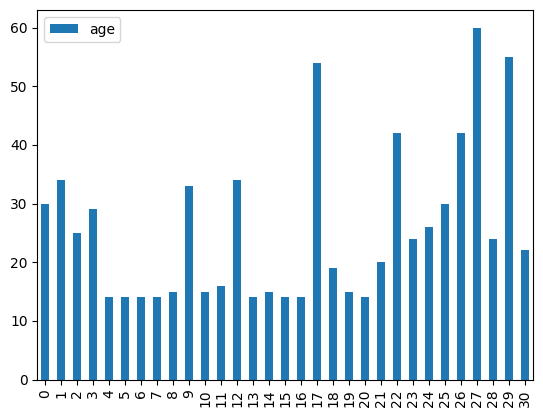

In [4]:
# ===========
# AVERAGE AGE
# ===========

age_list = []
for answers in frame["response"]:
    if isinstance(answers, str):
        try:
            parsed = ast.literal_eval(answers) 
            if isinstance(parsed, dict): # convert the strings to real dicts
                if "age" in parsed:
                    age_list.append(parsed)
        except (ValueError, SyntaxError):
            pass
df_age = pd.DataFrame(age_list)
df_age = df_age.drop([0, 1, 4, 18]) # remove unrealistic answers
df_age = df_age.reset_index(drop=True)
df_age["age"] = pd.to_numeric(df_age["age"])
print("Average age:", round(df_age["age"].mean(), 1))
df_age.plot.bar()

In [ ]:
# ===================
# DISPLAY Q-RESPONSES
# ===================
for answers in frame["response"]:
    if isinstance(answers, str):
        try:
            parsed = ast.literal_eval(answers) 
            if isinstance(parsed, dict): # convert the strings to real dicts
                if "Q0" in parsed and parsed["Q0"]:
                    print(parsed)
        except (ValueError, SyntaxError):
            pass

{'Q0': 'Sehr schwer'}
{'Q0': 'Serh scher!'}
{'Q0': 'schwer'}
{'Q0': 'die lieder klangen alle sehr gleich'}
{'Q0': 'schwierig aber spassig :)'}
{'Q0': 'Sehr schwer für Ungeübte\n'}
{'Q0': 'sehr gut\n'}
{'Q0': 'Megacoool und super innovativ, habt ihr echt super gemacht :)'}
{'Q0': 'Es ist schlicht und einfach nicht unterscheidbar, was ein Mensch und was eine KI komponiert hat. \nMich würde interessieren, wie die KI trainiert wurde, bestimmte Kriterien bei der Komposition zu erfüllen, z. B. Satz, Harmonie, Melodie, Akkorde usw. '}
{'Q0': 'sehr schwer aber gut:)'}
{'Q0': 'War supi :)'}
{'Q0': 'sher gut\n'}
{'Q0': 'es hat total spaß gemacht auch wenn ich denke dass ich ziemlich viel falsch getippt habe. War eine super Erfahrung, da ich das ganze Thema rund um KI super spannend finde.'}
{'Q0': 'Es hat Spaß gemacht und es wurde gut erklärt und war einfach zu verstehen und umzusetzen. Aber vllt kann man so nach 10 kurz pause machen, weil man sich dann nicht mehr so gut konzentrieren kann und d

In [12]:
frame["rt"].mean() / 1000

np.float64(9.64982142857143)